In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
np.random.seed(0)
data = pd.DataFrame({
    'TV': np.random.uniform(0, 100, 200),
    'Radio': np.random.uniform(0, 50, 200),
    'Sales': np.random.uniform(0, 30, 200)
})

In [3]:
median_sales = data['Sales'].median()
data['Sales_High'] = (data['Sales'] > median_sales).astype(int)


In [5]:
X = data[['TV', 'Radio']]
y = data['Sales_High']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [6]:
model = LogisticRegression()
model.fit(X_train_s, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [7]:
x_min, x_max = X['TV'].min() - 5, X['TV'].max() + 5
y_min, y_max = X['Radio'].min() - 5, X['Radio'].max() + 5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_points_s = scaler.transform(grid_points)

Z_class = model.predict(grid_points_s)
Z_prob = model.predict_proba(grid_points_s)[:, 1]

Z_class = Z_class.reshape(xx.shape)
Z_prob = Z_prob.reshape(xx.shape)

/home/lakshya/jupyter/paper/DFU/Patches/dfu/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


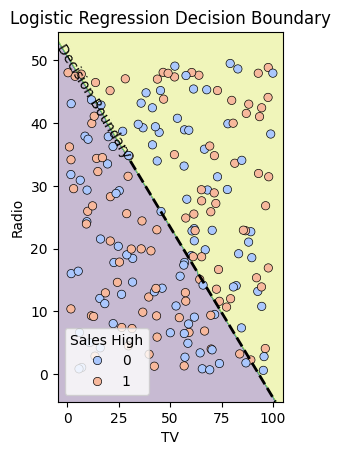

In [8]:
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z_class, alpha=0.3)
cs = plt.contour(xx, yy, Z_prob, levels=[0.5], colors='k', linewidths=2, linestyles='--')
plt.clabel(cs, fmt='Decision Boundary', inline=True)
sns.scatterplot(x='TV', y='Radio', hue='Sales_High', data=data, palette='coolwarm', edgecolor='k')
plt.title('Logistic Regression Decision Boundary')
plt.xlabel('TV')
plt.ylabel('Radio')
plt.legend(title='Sales High')


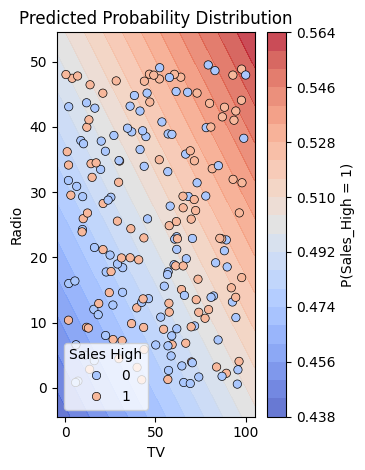

In [9]:
plt.subplot(1, 2, 2)
prob_plot = plt.contourf(xx, yy, Z_prob, levels=20, cmap='coolwarm', alpha=0.8)
plt.colorbar(prob_plot, label='P(Sales_High = 1)')
sns.scatterplot(x='TV', y='Radio', hue='Sales_High', data=data, palette='coolwarm', edgecolor='k')
plt.title('Predicted Probability Distribution')
plt.xlabel('TV')
plt.ylabel('Radio')
plt.legend(title='Sales High')

plt.tight_layout()
plt.show()